# Lab 2 Solutions: From Descriptive Statistics to Causal Thinking

This notebook provides the Python code to answer the specific questions posed in the **Second Lab** workshop document, moving from data exploration to causal questions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# Load dataset
df = pd.read_csv('smart_city_road_safety_synthetic_5000.csv')

for col in ["Traffic_Density", "Number_of_Vehicles", "Driver_Alcohol", "Accident"]:
    df[col] = df[col].astype(int)

## Part I: First Exploration of the Dataset

In [2]:
# 1. How many observations are in the dataset?
print(f"Total observations: {df.shape[0]}")

# 2 & 3. Types and Missing values
display(df.info())
print("\nMissing values:\n", df.isnull().sum())

# 4 & 5. Descriptive statistics
display(df.describe(include='all').T)

# 6. Proportion of accidents
print("\nProportion of Accidents:")
display(df['Accident'].value_counts(normalize=True))

Total observations: 5000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               5000 non-null   object 
 1   Road_Type             5000 non-null   object 
 2   Time_of_Day           5000 non-null   object 
 3   Traffic_Density       5000 non-null   int64  
 4   Speed_Limit           5000 non-null   float64
 5   Number_of_Vehicles    5000 non-null   int64  
 6   Driver_Alcohol        5000 non-null   int64  
 7   Accident_Severity     1310 non-null   object 
 8   Road_Condition        5000 non-null   object 
 9   Vehicle_Type          5000 non-null   object 
 10  Driver_Age            5000 non-null   float64
 11  Driver_Experience     5000 non-null   float64
 12  Road_Light_Condition  5000 non-null   object 
 13  Accident              5000 non-null   int64  
dtypes: float64(3), int64(4), object(7)
memory usage

None


Missing values:
 Weather                    0
Road_Type                  0
Time_of_Day                0
Traffic_Density            0
Speed_Limit                0
Number_of_Vehicles         0
Driver_Alcohol             0
Accident_Severity       3690
Road_Condition             0
Vehicle_Type               0
Driver_Age                 0
Driver_Experience          0
Road_Light_Condition       0
Accident                   0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Weather,5000,5,Clear,2048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Road_Type,5000,4,City Road,2236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time_of_Day,5000,4,Afternoon,1731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Traffic_Density,5000.0,NaN,NaN,NaN,1.2396,0.727116,0.0,1.0,1.0,2.0,2.0
Speed_Limit,5000.0,NaN,NaN,NaN,67.724,26.645109,30.0,50.0,60.0,80.0,120.0
Number_of_Vehicles,5000.0,NaN,NaN,NaN,4.1694,1.710581,1.0,3.0,4.0,5.0,11.0
Driver_Alcohol,5000.0,NaN,NaN,NaN,0.061,0.239354,0.0,0.0,0.0,0.0,1.0
Accident_Severity,1310,3,Low,779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Road_Condition,5000,4,Dry,2203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Type,5000,4,Car,3418,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Proportion of Accidents:


Accident
0    0.738
1    0.262
Name: proportion, dtype: float64

## Part II: Descriptive Road Safety Questions

### 3.1 Question 1: When do accidents occur more frequently?

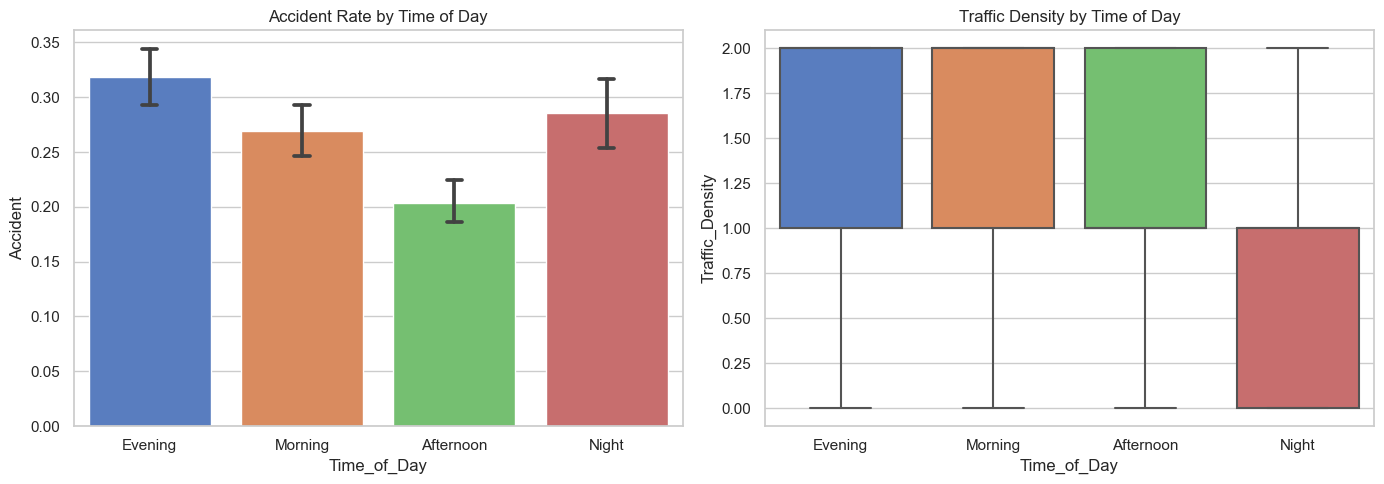

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of accident rate by Time_of_Day
sns.barplot(data=df, x='Time_of_Day', y='Accident', ax=ax1, capsize=0.1)
ax1.set_title("Accident Rate by Time of Day")

# Boxplot of Traffic Density by Time of Day
sns.boxplot(data=df, x='Time_of_Day', y='Traffic_Density', ax=ax2)
ax2.set_title("Traffic Density by Time of Day")

plt.tight_layout()
plt.show()

### 3.2 Question 2: Are some road conditions associated with more accidents?

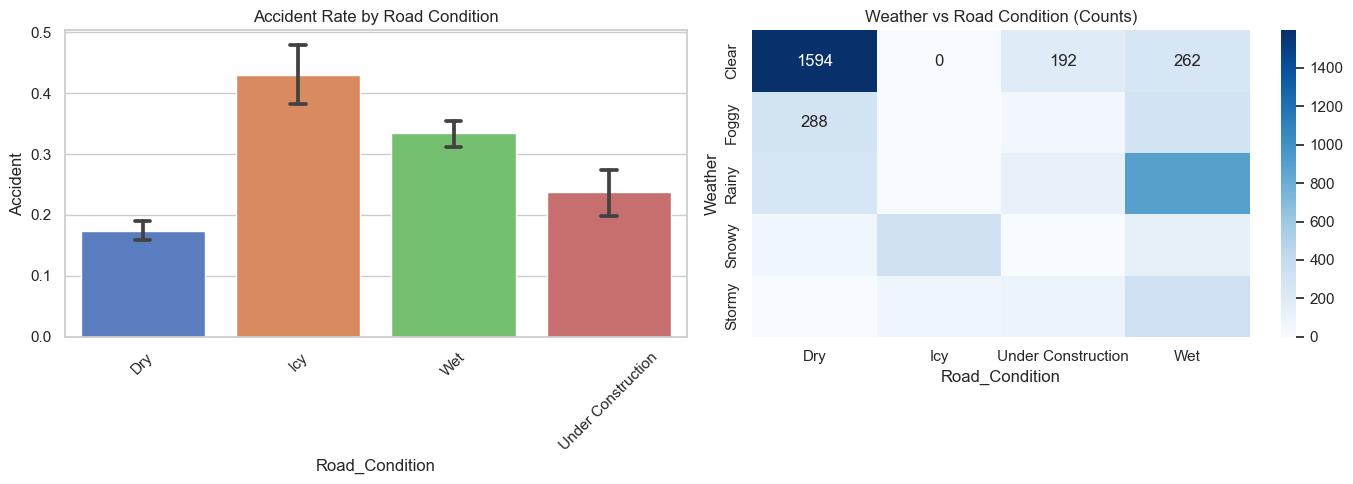

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accident rate by Road Condition
sns.barplot(data=df, x='Road_Condition', y='Accident', ax=ax1, capsize=0.1)
ax1.set_title("Accident Rate by Road Condition")
ax1.tick_params(axis='x', rotation=45)

# Heatmap comparing Weather and Road Condition frequencies
cross_tab = pd.crosstab(df['Weather'], df['Road_Condition'])
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="Blues", ax=ax2)
ax2.set_title("Weather vs Road Condition (Counts)")

plt.tight_layout()
plt.show()

### 3.3 Question 3: Does road lighting seem related to accident risk?

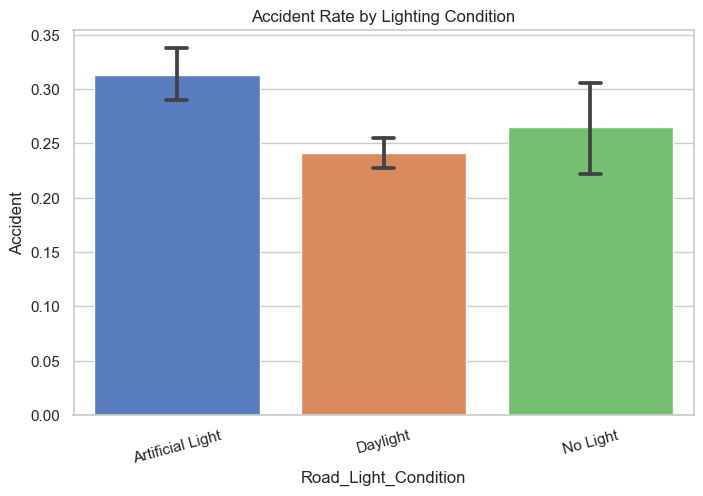

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x='Road_Light_Condition', y='Accident', capsize=0.1, ax=ax)
ax.set_title("Accident Rate by Lighting Condition")
ax.tick_params(axis='x', rotation=15)
plt.show()

### 3.4 Question 4: Are driver characteristics associated with accident risk?

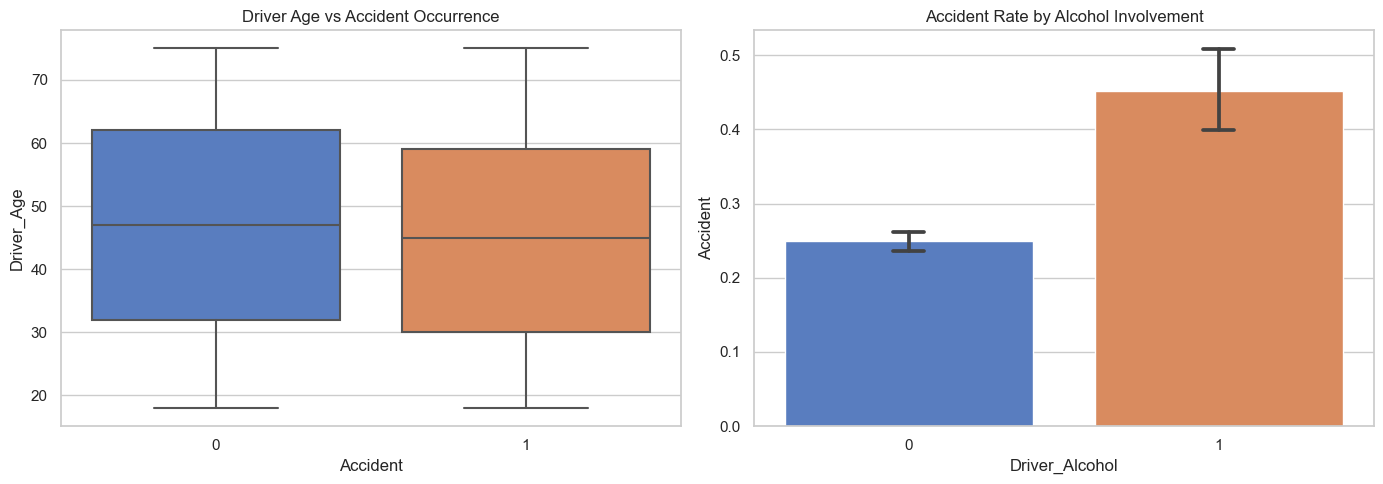

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot of Driver Age by Accident
sns.boxplot(data=df, x='Accident', y='Driver_Age', ax=ax1)
ax1.set_title("Driver Age vs Accident Occurrence")

# Bar chart of accident rate by Driver Alcohol
sns.barplot(data=df, x='Driver_Alcohol', y='Accident', capsize=0.1, ax=ax2)
ax2.set_title("Accident Rate by Alcohol Involvement")

plt.tight_layout()
plt.show()

### 3.5 Question 5: How do traffic variables relate to accident risk?

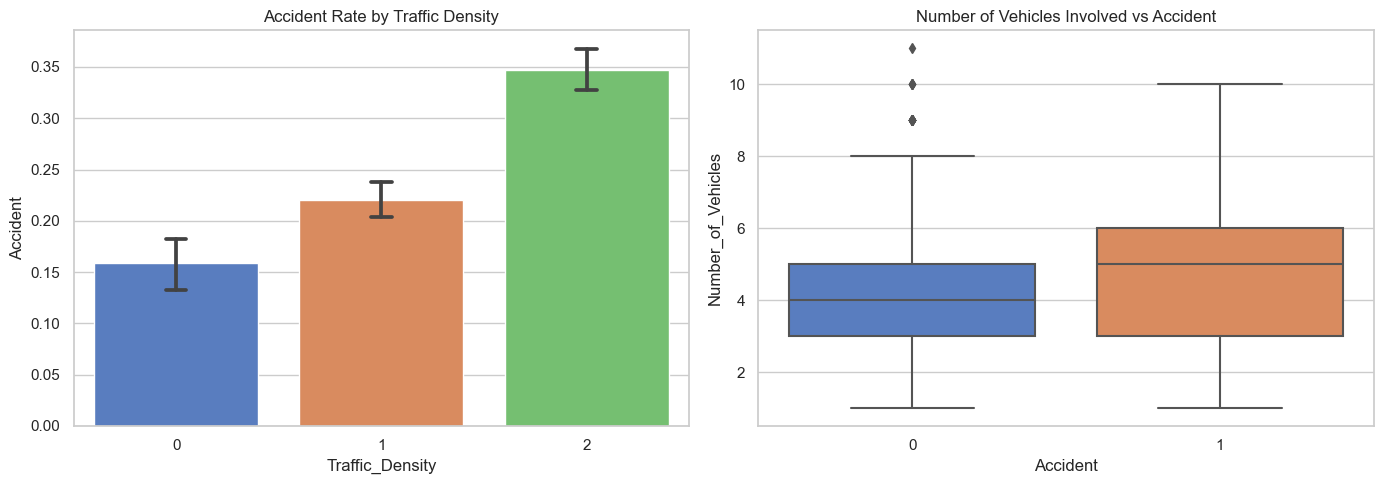

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accident rate by Traffic Density
sns.barplot(data=df, x='Traffic_Density', y='Accident', capsize=0.1, ax=ax1)
ax1.set_title("Accident Rate by Traffic Density")

# Boxplot of Number of Vehicles by Accident
sns.boxplot(data=df, x='Accident', y='Number_of_Vehicles', ax=ax2)
ax2.set_title("Number of Vehicles Involved vs Accident")

plt.tight_layout()
plt.show()

## Part III: From Descriptive Questions to Causal Questions

The lab document contrasts the observed association:
$$P(\text{Accident} = 1 | \text{Road\_Light\_Condition})$$

With the causal intervention:
$$P(\text{Accident} = 1 | do(\text{Road\_Light\_Condition}))$$

Let's see why this matters using Simpson's Paradox. We will simulate a 'Smart Lighting' intervention.

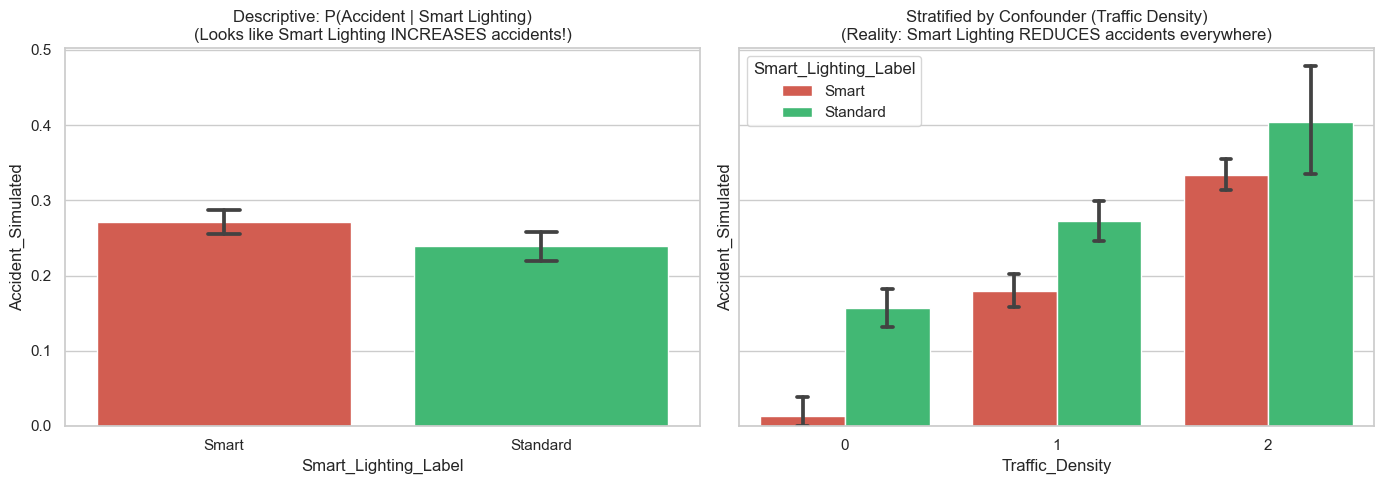

In [8]:
# Pedagogical Simulation of Confounding
np.random.seed(42)

# Let's pretend Smart Lighting was installed mostly in High Traffic Density areas (because of budget)
probs = {0: 0.1, 1: 0.5, 2: 0.9}
df["Smart_Lighting"] = [np.random.binomial(1, probs[t]) for t in df["Traffic_Density"]]

# True causal mechanism: Smart Lighting REDUCES risk by 10%, but High Traffic INCREASES risk by 30%
base_risk = 0.15 + 0.30 * (df["Traffic_Density"] / 2) # Scaling density to 0-1
smart_light_effect = -0.10
final_risk = base_risk + smart_light_effect * df["Smart_Lighting"]

df["Accident_Simulated"] = [np.random.binomial(1, np.clip(p, 0, 1)) for p in final_risk]
df["Smart_Lighting_Label"] = df["Smart_Lighting"].map({0: "Standard", 1: "Smart"})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# The Naive Descriptive View P(Y | X)
sns.barplot(data=df, x="Smart_Lighting_Label", y="Accident_Simulated", capsize=0.1, palette=["#e74c3c", "#2ecc71"], ax=ax1)
ax1.set_title("Descriptive: P(Accident | Smart Lighting)\n(Looks like Smart Lighting INCREASES accidents!)")

# The Stratified View (Moving towards P(Y | do(X)))
sns.barplot(data=df, x="Traffic_Density", y="Accident_Simulated", hue="Smart_Lighting_Label", capsize=0.05, palette=["#e74c3c", "#2ecc71"], ax=ax2)
ax2.set_title("Stratified by Confounder (Traffic Density)\n(Reality: Smart Lighting REDUCES accidents everywhere)")

plt.tight_layout()
plt.show()